In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.io as io
import argparse
import sys
from tqdm import tqdm

import src.utils.utils as utils
import src.training.training as training
import src.utils.extractor as extractor
import src.models.models as models
import src.models.foundation_models as rsfm

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

Using device: cuda:0


In [20]:
dataset = "urban"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float32)
# Y_flat = utils.normalize(Y_flat)
E = torch.tensor(data["E"])
A_flat = torch.tensor(data["A"])
B, c, N = E.shape[0], E.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
A = utils.oneD_to_2d(A_flat)
H = Y_init.shape[-1]
Y_init = Y_init.to(torch.float32)
Y_init = Y_init.unsqueeze(0)
# Y = Y/ Y.max()

In [21]:
class CNNAEU2(nn.Module):
    def __init__(self, B, c, H, E_init=None, use_cnn=False):
        super().__init__()

        self.B = B
        self.c = c
        self.H = H
        self.use_cnn = use_cnn

        self.encoder = nn.Sequential(
            nn.Conv2d(self.B, 48, kernel_size=3, padding=1, padding_mode="reflect", bias=False),
            nn.LeakyReLU(),
            nn.BatchNorm2d(48),
            nn.Dropout2d(p=0.2),
            nn.Conv2d(48, self.c, kernel_size=1, bias=False),
            nn.LeakyReLU(),
            nn.BatchNorm2d(self.c),
            nn.Dropout2d(p=0.2),
        )
        self.decoder = nn.Conv2d(self.c, self.B, kernel_size=11, padding=5, padding_mode="reflect", bias=False)
        # self.decoder = rsfm.Decoder(self.c, self.B)

        if E_init != None:
            state_dict = self.decoder.state_dict()
            state_dict["weight"] = E_init.unsqueeze(-1).unsqueeze(-1).expand(self.B, self.c, 11, 11)
            # state_dict["decoder.weight"][:, :, 0, 0] = E_init
            self.decoder.load_state_dict(state_dict)

        if self.use_cnn:
            self.norm = nn.LayerNorm([self.B, self.H, self.H])
            self.encoder2 = nn.Sequential(
                nn.Conv2d(self.B, 48, kernel_size=3, padding=1, padding_mode="reflect", bias=False),
                nn.LeakyReLU(),
                nn.Dropout2d(p=0.2),
                nn.Conv2d(48, self.c, kernel_size=1, bias=False),
                nn.LeakyReLU(),
                nn.Dropout2d(p=0.2),
            )
            self.decoder2 = rsfm.Decoder(self.c, self.B)

        else:
            self.encoder2 = nn.Linear(self.B, self.c)
            self.decoder2 = nn.Linear(self.c, self.B, bias=False)   
    
    def freeze1(self):
        # Freeze first part
        for param in self.encoder.parameters():
            param.requires_grad = False
        for param in self.decoder.parameters():
            param.requires_grad = False

        # Unfreeze second encoder
        for param in self.encoder2.parameters():
            param.requires_grad = True
        for param in self.decoder2.parameters():
            param.requires_grad = False

    def freeze2(self):
        # Freeze second part
        for param in self.encoder2.parameters():
            param.requires_grad = False
        for param in self.decoder2.parameters():
            param.requires_grad = False

        # Unfreeze first part
        for param in self.encoder.parameters():
            param.requires_grad = True
        for param in self.decoder.parameters():
            param.requires_grad = True
    
    @staticmethod
    def loss(E_gt, E_hat, A_gt, A_hat, Y_gt, Y_hat):
        sad = utils.SADLoss()
        return sad(Y_gt, Y_hat)
    
    def forward1(self, x):
        # Input shape (batch, B, N)
        
        if x.dim() < 3:
            x = x.unsqueeze(0) # Add a batch dimension for inference
        
        batch, B, N = x.shape
        x = utils.oneD_to_2d(x)
        code = self.encoder(x)
        
        abund = F.softmax(code, dim=1)
        a_hat = abund.reshape(batch, self.c, N)
        
        x_hat = self.decoder(abund)
        x_hat = x_hat.reshape(batch, B, N)
        
        e_hat = self.decoder.weight.detach().mean((2, 3)).reshape(batch, self.B, self.c)
        # e_hat = self.decoder.get_endmembers()
        
        return e_hat, a_hat, x_hat

    def forward2(self, x):
        
        if x.dim() < 3:
            x = x.unsqueeze(0)

        if self.use_cnn:
            batch, _, N = x.shape
            x = utils.oneD_to_2d(x)
            x = x/torch.max(x)
            # x = self.norm(x)

            code = self.encoder2(x)
            A_hat = F.softmax(code, dim=1)
            Y_hat = self.decoder2(A_hat)

            A_hat = A_hat.reshape(batch, self.c, N)
            Y_hat = Y_hat.reshape(batch, self.B, N)
            E_hat = self.decoder2.get_endmembers()

        else:
            batch, _, N = x.shape
            x_reshaped = x.permute(0, 2, 1).reshape(-1, self.B)
            A_hat = self.encoder2(x_reshaped)
            A_hat = F.softmax(A_hat)
            Y_hat = self.decoder2(A_hat)
            E_hat = self.decoder2.weight    

            A_hat = A_hat.view(batch, N, self.c).permute(0, 2, 1)
            Y_hat = Y_hat.view(batch, N, self.B).permute(0, 2, 1)

        return E_hat, A_hat, Y_hat

SAD = 0.23274913430213928 ± 0.020078355446457863, MSE = 0.5260997414588928 ± 0.1521546095609665


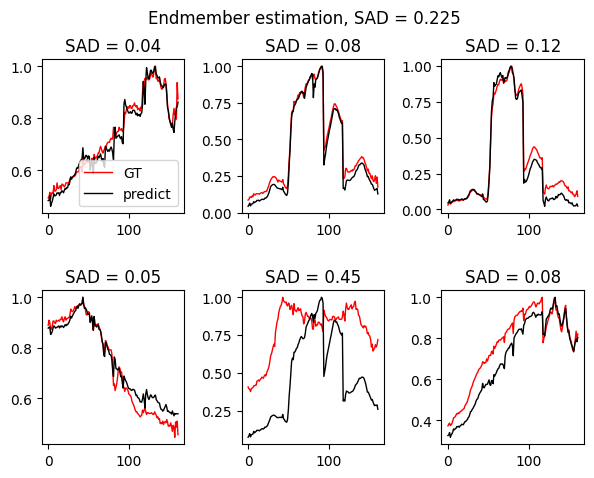

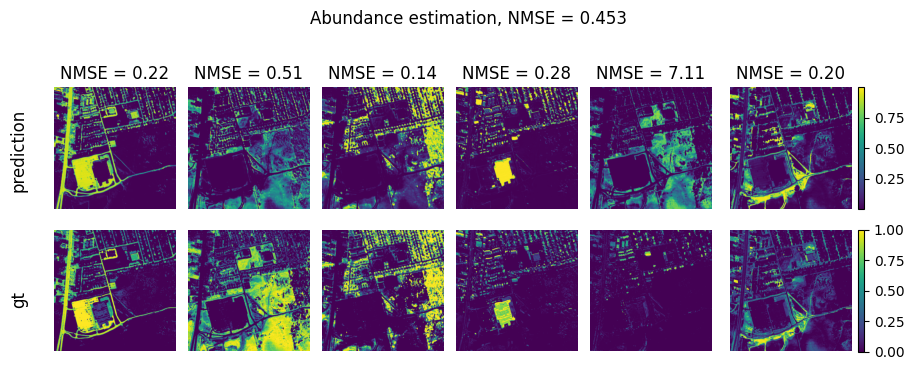

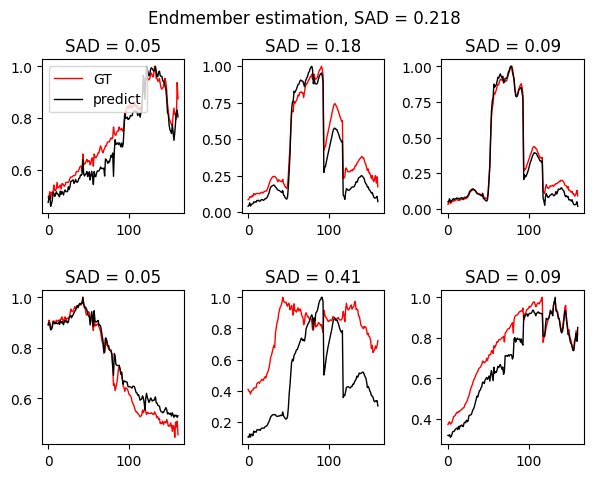

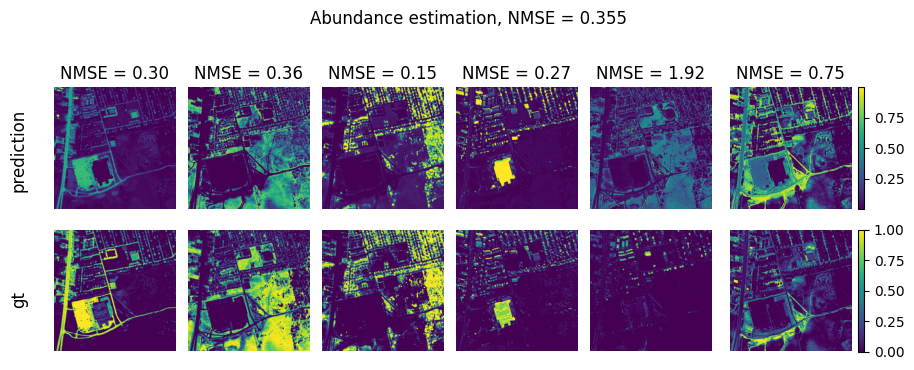

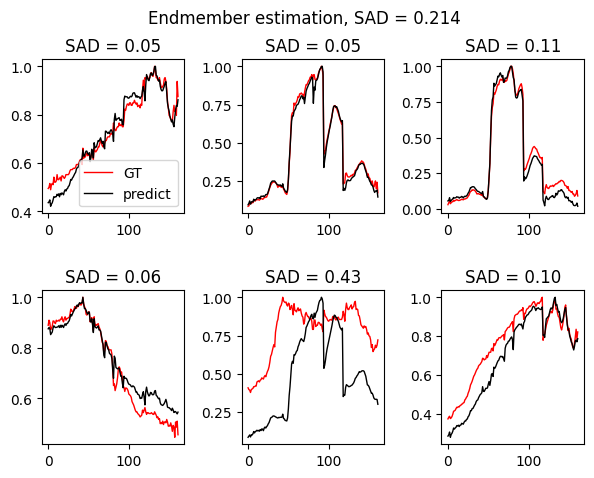

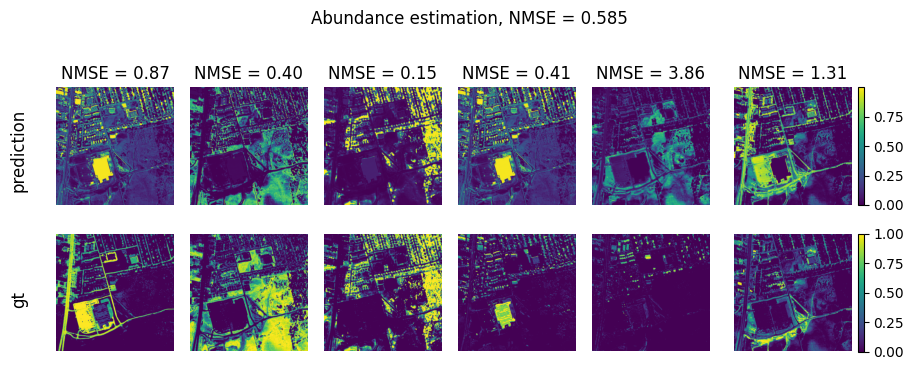

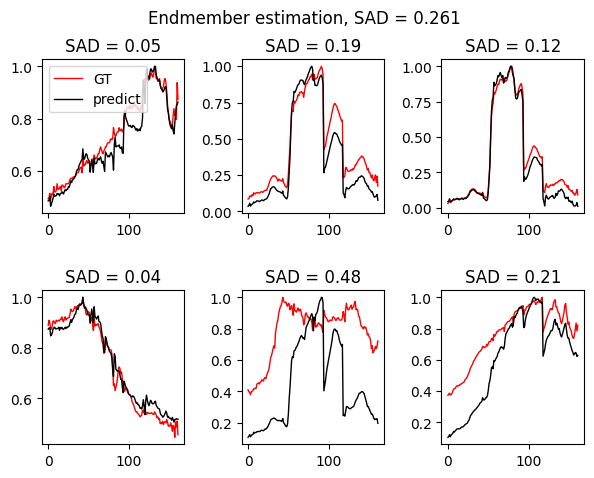

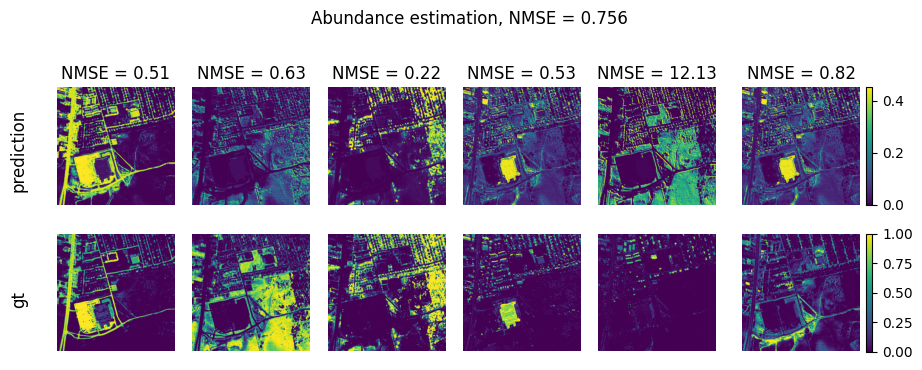

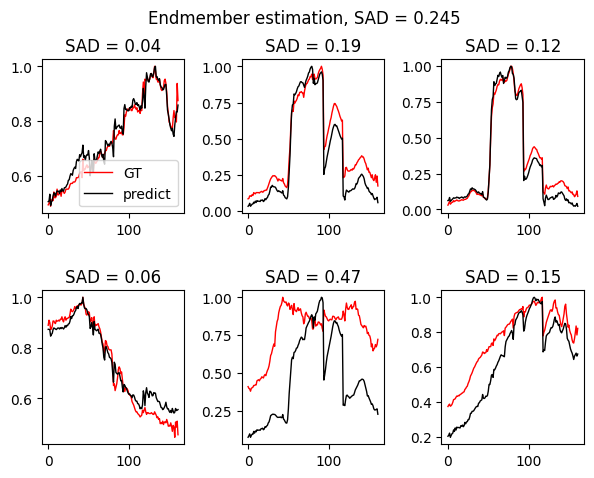

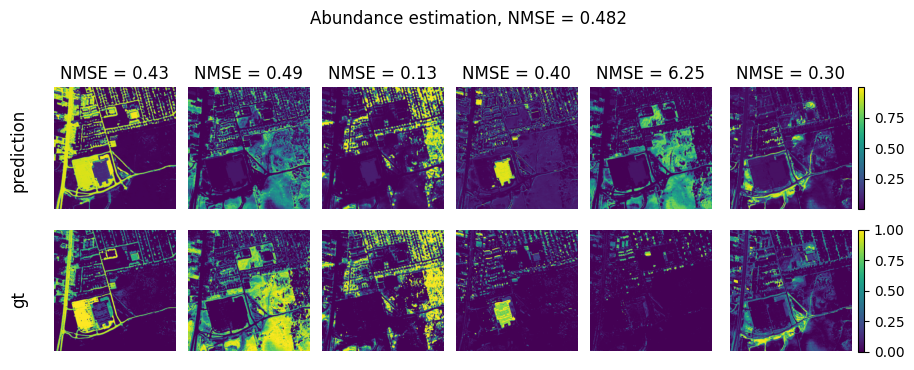

In [23]:
n_xp = 5
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev)
sads, mses = [], []

for n in range(n_xp):

    E_init = extractor.VCA(Y_init, c)
    model = CNNAEU2(B, c, H=Y.shape[2], E_init=None, use_cnn=False)
    model.freeze2()

    train_losses = []

    epochs, lr = 500, 0.01
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-3)

    for epoch in range(epochs):
        
        train_loss = 0
        
        for Y, E, A in loader:
            optimizer.zero_grad()
            
            Y = Y.to(dev)
            A = A.to(dev)
            E = E.to(dev)

            E_hat, A_hat, Y_hat = model.forward1(Y)
            
            loss = model.loss(E, E_hat, A, A_hat, Y, Y_hat)
            train_loss += loss.item()

            # if epoch%(epochs//10)==0:
            #     print(f"Epoch {epoch}: total = {format(loss, '.3f')}")
            
            loss.backward()
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
            break

        train_loss /= len(loader)
        train_losses.append(train_loss)
    # plt.plot(train_losses)

    E_hat_cnn, A_hat_cnn, Y_hat_cnn = model.forward1(Y)
    A_hat_cnn = utils.oneD_to_2d(A_hat_cnn)
    A = utils.oneD_to_2d(A)
    sad, mse = utils.plot_results(E_hat_cnn, A_hat_cnn, A, E, normalize_E=True, return_results=True)
    sads.append(sad)
    mses.append(mse)

print(f"SAD = {torch.mean(torch.tensor(sads))} ± {torch.std(torch.tensor(sads))}, MSE = {torch.mean(torch.tensor(mses))} ± {torch.std(torch.tensor(mses))}")

Epoch 0: total = 0.387
Epoch 40: total = nan
Epoch 80: total = nan
Epoch 120: total = nan
Epoch 160: total = nan
Epoch 200: total = nan
Epoch 240: total = nan
Epoch 280: total = nan
Epoch 320: total = nan
Epoch 360: total = nan


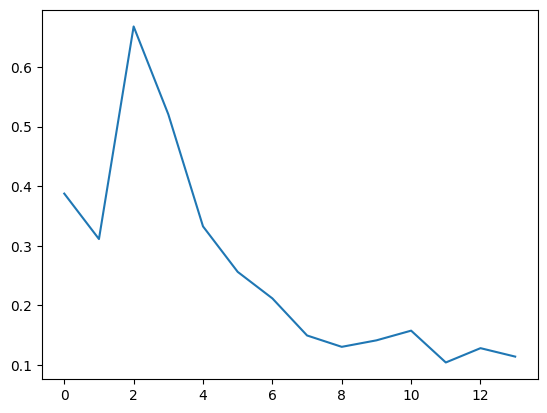

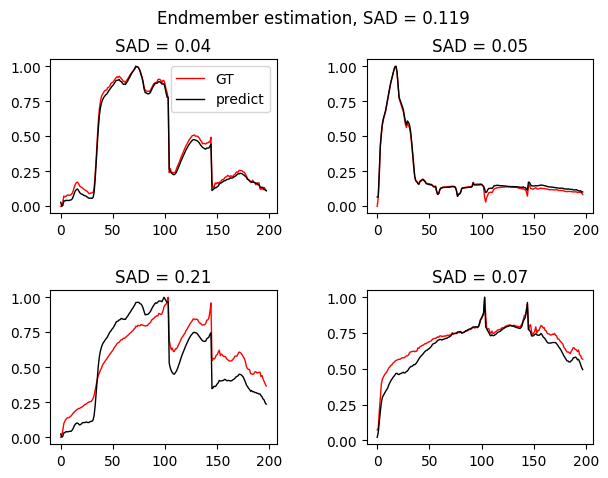

Error in callback <function flush_figures at 0x7f500c6930a0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [234]:
model.freeze1()
state_dict = model.decoder2.state_dict()
state_dict["weight"] = model.decoder.weight.detach().mean((2, 3)).reshape(B, c)
# state_dict["decoder.weight"][:, :, 0, 0] = model.decoder.get_endmembers()
model.decoder2.load_state_dict(state_dict)

train_losses = []
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev)

epochs, lr = 400, 0.001
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

for epoch in range(epochs):
    
    train_loss = 0
    
    for Y, E, A in loader:
        optimizer.zero_grad()
        
        Y = Y.to(dev)
        A = A.to(dev)
        E = E.to(dev)

        _, _, Y = model.forward1(Y)
        E_hat, A_hat, Y_hat = model.forward2(Y)
        
        loss = model.loss(E, E_hat, A, A_hat, Y, Y_hat)
        train_loss += loss.item()

        if epoch%(epochs//10)==0:
            print(f"Epoch {epoch}: total = {format(loss, '.3f')}")
        
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
        break

    train_loss /= len(loader)
    train_losses.append(train_loss)
plt.plot(train_losses)

E_hat_cnn, A_hat_cnn, Y_hat_cnn = model.forward2(Y)
A = utils.oneD_to_2d(A)
A_hat_cnn = utils.oneD_to_2d(A_hat_cnn)
utils.plot_results(E_hat_cnn, A_hat_cnn, A, E, normalize_E=True)

In [229]:
print("The unmixer model has : ", format(sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6, '.2f'), "M trainable params")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, ': ', format(param.numel()/1e3, '.2f'), "k params")

The unmixer model has :  0.00 M trainable params
encoder2.weight :  0.79 k params
encoder2.bias :  0.00 k params
